In [3]:
import logging
import argparse

import torch

from lib.config import Config
from lib.runner import Runner
from lib.experiment import Experiment
import sys

import time
import os
import sys

import torch
# from model.lanenet.train_lanenet import train_model
# from dataloader.data_loaders import TusimpleSet
# from dataloader.transformers import Rescale
# from model.lanenet.LaneNet import LaneNet

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch.utils.data import DataLoader, Dataset

from torch.autograd import Variable
from PIL import Image
from torchvision import transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    A = None
    ToTensorV2 = None

# from model.utils.cli_helper import parse_args
# from model.eval_function import Eval_Score
import sys
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt


DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
from scipy.ndimage import binary_dilation, label
from matplotlib.patches import Patch
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random
import json
from PIL import Image

from lib.config import Config

import warnings
warnings.filterwarnings('ignore')

/Users/amannindra/miniconda3/envs/Lannet310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


In [4]:
def get_files(segment_folder):
    return [path for path in segment_folder.iterdir() if path.is_file()]
def get_directories(cipo_path):
    return [path for path in cipo_path.iterdir() if path.is_dir()]
def remove_first_parent(path: Path) -> Path:
    return Path(*path.parts[1:])
def check_dir(check):
    if check.is_dir():
        print(f"Directory Found: {check}")
    else:
        print(f"Directory Not Found: {check}")
def check_file(check):
    if check.is_file():
        print(f"File Found: {check}")
    else:
        print("File Not Found")


# model_path = Path("/Users/amannindra/Projects/Auto/Autonomous-Bicycle/LaneATT/experiments/Testing/models/model_0020.pt")

#check_file(model_path)

In [5]:
def lanes_to_px(lanes, w, h):
    out = []
    for lane in lanes:
        pts = lane.points.copy().astype(float)
        pts[:, 0] *= w          # Lane.points are normalized (x, y) in [0, 1]
        pts[:, 1] *= h
        out.append(pts.round().astype(int))
    return out

In [7]:
config_path = "/Users/amannindra/Projects/Auto/Autonomous-Bicycle/LaneATT/experiments/Testing_Pinnacle/config.yaml"

cfg = Config(config_path)
exp = Experiment(exp_name = "Testing_Pinnacle", args = None, mode="eval")
device = torch.device('cpu')
model = cfg.get_model()
# print(model)
runner = Runner(cfg, exp, device, view=True, resume=False, deterministic=False)
print("Runner is intialized")
# model = runner.eval(epoch = 7)

# print(type(model))

Runner is intialized


In [8]:
ckpt = torch.load(exp.get_checkpoint_path(7), map_location='cpu')['model']
print(torch.equal(model.reg_layer.weight.detach().cpu(), ckpt['reg_layer.weight']))  # -> True

False


In [9]:
infer_params = dict(cfg.get_test_parameters())# {'conf_threshold':0.5,'nms_thres':50.,'nms_topk':4}
infer_params['conf_threshold'] = 0
test_dataset = cfg.get_dataset('test2')
print(infer_params)
print(type(infer_params))


[2026-07-13 19:54:34,239] [lib.datasets.culane] [INFO] Indexing CULane test2 annotations (lazy loading)...
[2026-07-13 19:54:34,241] [lib.datasets.culane] [INFO] 6 annotations indexed.


self.config['datasets'][split]['type'] LaneDataset
{'conf_threshold': 0, 'nms_thres': 50.0, 'nms_topk': 4}
<class 'dict'>


In [10]:


n_show = 6
# plt.figure(figsize=(18, 8))
# with torch.no_grad():
#     for idx in range(n_show):
#         img_t, label, _ = test_dataset[idx]
#         x = img_t.unsqueeze(0).to(device)
#         print(x.shape)

#         output = model(x, **infer_params)
#         pred_lanes = model.decode(output, as_lanes=True)[0]   # predicted Lane objects
#         gt_lanes   = test_dataset.label_to_lanes(label)        # ground-truth Lane objects

#         n_props = output[0][0].shape[0]                        # proposals surviving NMS
#         print(f"idx {idx}: {n_props} proposals after NMS -> {len(pred_lanes)} decoded lanes")

#         # build a displayable RGB image from the model's own input tensor (normalize:false in cfg)
#         img = (img_t.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()       # cv2.imread loads BGR

#         for pts in lanes_to_px(gt_lanes,   img.shape[1], img.shape[0]):   # GT = blue
#             for p0, p1 in zip(pts[:-1], pts[1:]):
#                 cv2.line(img, tuple(p0), tuple(p1), (0, 0, 255), 2)
#         for pts in lanes_to_px(pred_lanes, img.shape[1], img.shape[0]):   # pred = green
#             for p0, p1 in zip(pts[:-1], pts[1:]):
#                 cv2.line(img, tuple(p0), tuple(p1), (0, 255, 0), 3)

#         ax = plt.subplot(2, 3, idx + 1)
#         ax.imshow(img)
#         ax.set_title(f"idx {idx}: {len(pred_lanes)} pred (green) / {len(gt_lanes)} GT (blue)")
#         ax.axis('off')
# plt.tight_layout(); plt.show()

In [11]:
s = {"dsa": 3, "sdsasa": 42, "dsda": 42}

s.values()

dict_values([3, 42, 42])

In [12]:
from lib.yolo import YoloInference
from pathlib import Path
from PIL import Image
wieght = "/Users/amannindra/Projects/Auto/Autonomous-Bicycle/Yolov11/runs/yolo11n_coco45/weights/last.pt"

model = YoloInference(wieght, 0.5)

path = "/Users/amannindra/Projects/Auto/100k_images/test"

folder = Path(path)

# 2. Get only files (excludes subfolders)
files = [f for f in folder.iterdir() if f.is_file()]
output = model.infer(files[0])
print(type(output))
print(output)


image 1/1 /Users/amannindra/Projects/Auto/100k_images/test/e43a15ab-a06fecc7.jpg: 384x640 8 vehicles, 48.7ms
Speed: 3.1ms preprocess, 48.7ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)
<class 'list'>
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'vehicle', 2: 'traffic-light', 3: 'stop-sign'}
obb: None
orig_img: array([[[ 50,  71,  63],
        [ 45,  66,  58],
        [ 52,  73,  65],
        ...,
        [134, 132, 138],
        [ 87,  85,  91],
        [ 71,  69,  75]],

       [[ 37,  58,  50],
        [ 38,  59,  51],
        [ 47,  68,  60],
        ...,
        [147, 145, 151],
        [ 91,  89,  95],
        [ 68,  66,  72]],

       [[ 35,  56,  48],
        [ 39,  60,  52],
        [ 40,  61,  53],
        ...,
        [179, 177, 183],
        [120, 118, 124],
        [ 93,  91,  97]],

       ...,

       [[ 45,  44,  46],
        [ 45,  44,

In [13]:
output[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1., 1., 1., 1., 1.])
conf: tensor([0.9214, 0.9053, 0.8814, 0.8689, 0.7857, 0.6049, 0.5885, 0.5647])
data: tensor([[4.9691e+02, 3.2916e+02, 7.1321e+02, 5.0689e+02, 9.2143e-01, 1.0000e+00],
        [9.0381e+02, 3.0749e+02, 1.2026e+03, 4.8468e+02, 9.0530e-01, 1.0000e+00],
        [1.1073e+03, 3.1190e+02, 1.2796e+03, 5.6735e+02, 8.8138e-01, 1.0000e+00],
        [8.1339e+02, 3.1021e+02, 9.6782e+02, 4.3010e+02, 8.6894e-01, 1.0000e+00],
        [7.6350e+02, 3.3564e+02, 8.3822e+02, 4.0611e+02, 7.8571e-01, 1.0000e+00],
        [4.2764e+02, 3.1642e+02, 4.9416e+02, 3.7597e+02, 6.0494e-01, 1.0000e+00],
        [3.2691e+02, 3.3826e+02, 3.7661e+02, 3.6584e+02, 5.8846e-01, 1.0000e+00],
        [6.7638e+02, 3.3116e+02, 7.3347e+02, 3.7219e+02, 5.6466e-01, 1.0000e+00]])
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([8, 6])
xywh: tensor([[ 605.0566,  418.0266,  216.3025,  177.7347],
        [1053.1797,

In [14]:
frame = model.draw(Image.open(files[0]), output)

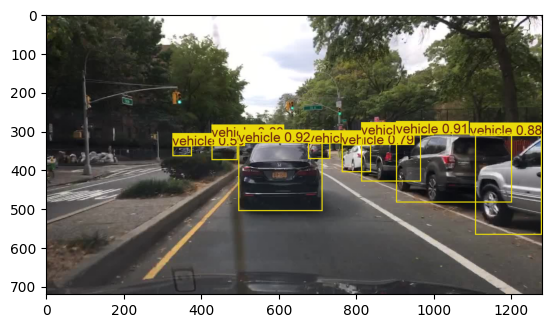

In [15]:
import matplotlib.pyplot as plt 


plt.imshow(frame)

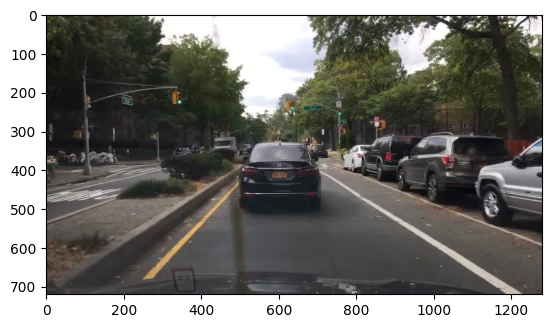

In [17]:
plt.imshow(Image.open(files[0]))

In [ ]:
folder_images = Path("/Users/amannindra/Projects/Auto/100k_images")
folder_json = Path("/Users/amannindra/Projects/Auto/100k_json")

culane = Path("/Users/amannindra/Projects/Auto/CuLaneDataset")

train_json = folder_json / Path("train")

json_data = get_files(train_json)

print(json_data[0])

with

/Users/amannindra/Projects/Auto/100k_json/train/3649af95-2ee578d7.json
